In [67]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [68]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [70]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=1/n #calculate_tolerance(points) # 1/(n-1) #1e-5
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
    return len(distinct_points), distinct_points

In [71]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [72]:
main_path = "../GSM/solns_runs/Ex1/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [73]:
folders= ["../GSM/solns_runs/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex1/N_100/',
 '../GSM/solns_runs/Ex1/N_200/',
 '../GSM/solns_runs/Ex1/N_300/',
 '../GSM/solns_runs/Ex1/N_400/',
 '../GSM/solns_runs/Ex1/N_500/',
 '../GSM/solns_runs/Ex1/N_600/',
 '../GSM/solns_runs/Ex1/N_700/',
 '../GSM/solns_runs/Ex1/N_800/',
 '../GSM/solns_runs/Ex1/N_900/',
 '../GSM/solns_runs/Ex1/N_1000/',
 '../GSM/solns_runs/Ex1/N_1100/',
 '../GSM/solns_runs/Ex1/N_1200/',
 '../GSM/solns_runs/Ex1/N_1300/',
 '../GSM/solns_runs/Ex1/N_1400/',
 '../GSM/solns_runs/Ex1/N_1500/']

In [74]:
import os

def list_txt_files_in_directory(directory_path):
    files_and_directories = os.listdir(directory_path)
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [75]:
eps_t= 1e-5
def get_accuracy(setXYP):
    acc= 0.0
    for i in range(len(setXYP)):
        if (0.5 <= setXYP[i][0] <=1.0 and (1-setXYP[i][0]-setXYP[i][1])<eps_t)== True:
            acc+= 1
    return (acc/len(setXYP))*100

In [76]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')    
    ax1.set_ylabel('Perentage of distint points',color='blue')
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])


    plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
    plt.grid(True)
    plt.show()

    return dist_,avg_hd,accuracy_list

275 1000
557 2000
848 3000
1124 4000
1444 5000
1694 6000
1995 7000
2264 8000
2548 9000
2843 10000
3100 11000
3431 12000
3673 13000
3915 14000
4161 15000


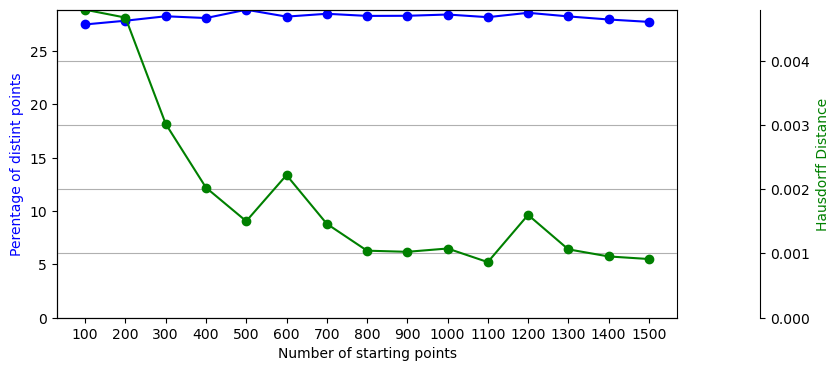

In [77]:
pdpgsm, hdgsm,accuracygsm= get_values(folders)

In [78]:
for (p,h,acc) in zip(pdpgsm, hdgsm,accuracygsm):
    print(p, " * ", h, " * ", acc)

27.500000000000004  *  0.004794423793149157  *  99.63636363636364
27.85  *  0.0046717068392724045  *  99.82046678635548
28.26666666666667  *  0.00301656625445407  *  99.88207547169812
28.1  *  0.0020250804623738604  *  100.0
28.88  *  0.0015029806232917267  *  99.93074792243767
28.233333333333334  *  0.002220252074153003  *  99.88193624557262
28.499999999999996  *  0.0014624315581571864  *  99.8997493734336
28.299999999999997  *  0.0010437110095035268  *  99.91166077738515
28.31111111111111  *  0.0010258811268936303  *  99.9215070643642
28.43  *  0.0010774644775225337  *  99.92965177629264
28.18181818181818  *  0.0008658309258466274  *  99.83870967741936
28.591666666666665  *  0.001600660254660031  *  99.82512387059165
28.25384615384615  *  0.0010640764678304744  *  99.863871494691
27.964285714285715  *  0.0009539364429110642  *  99.87228607918263
27.74  *  0.0009137200624563548  *  99.85580389329488


In [79]:
max(pdpgsm), min(hdgsm), max(accuracygsm)

(28.88, 0.0008658309258466274, 100.0)

In [80]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
            
        all_solns.append(distinct_points)
        
    
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.grid(True)
        plt.show()

In [81]:
## Plot solution sets
#plot_solns(folders)

In [82]:
nubmer_points_list[np.argmax(pdpgsm)]

500

## Histograms

In [83]:
# n_runs= 50 and 
# n_points= 1500 #nubmer_points_list[np.argmax(pdpgsm)]
n_points= nubmer_points_list[np.argmax(pdpgsm)]
# Best
directory_path = "../GSM/solns_runs/Ex1/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
for file in files:
    solns= np.genfromtxt(file, delimiter=',')
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)
num, all_solnsgsm= count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)

In [84]:
len(all_solnsgsm)

1444

In [85]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

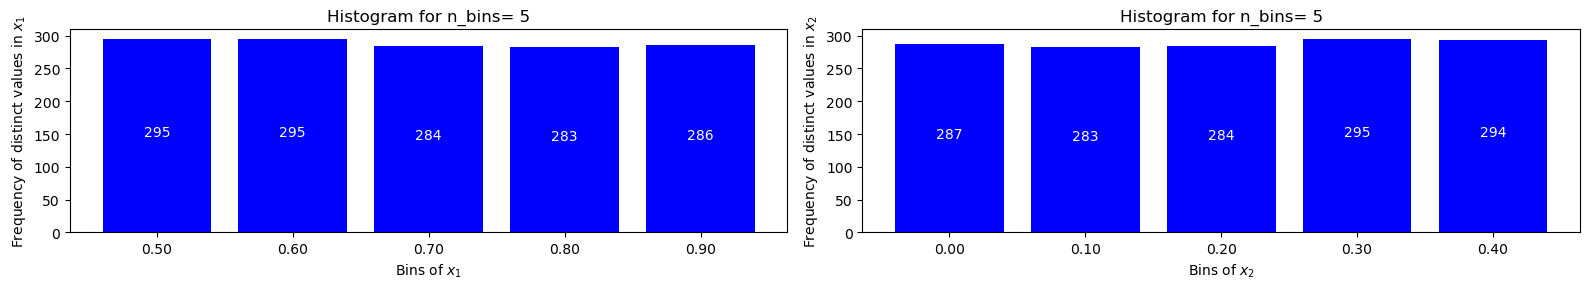

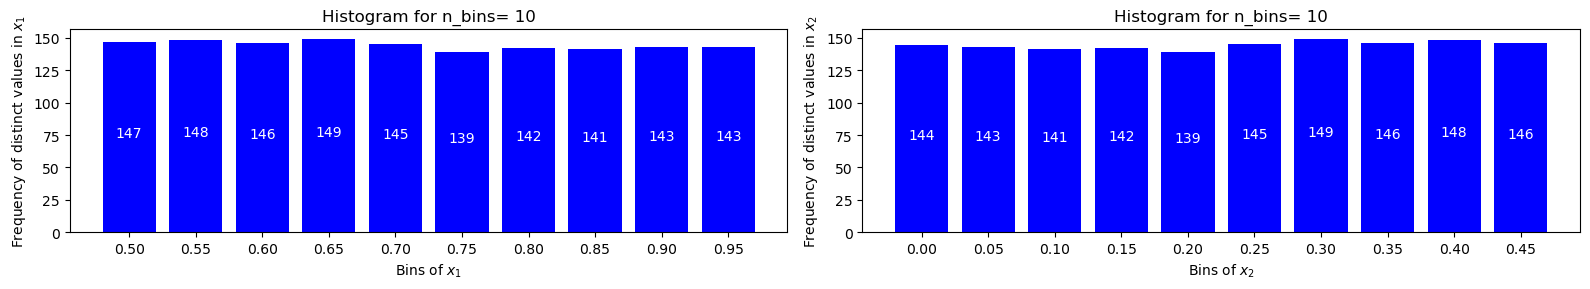

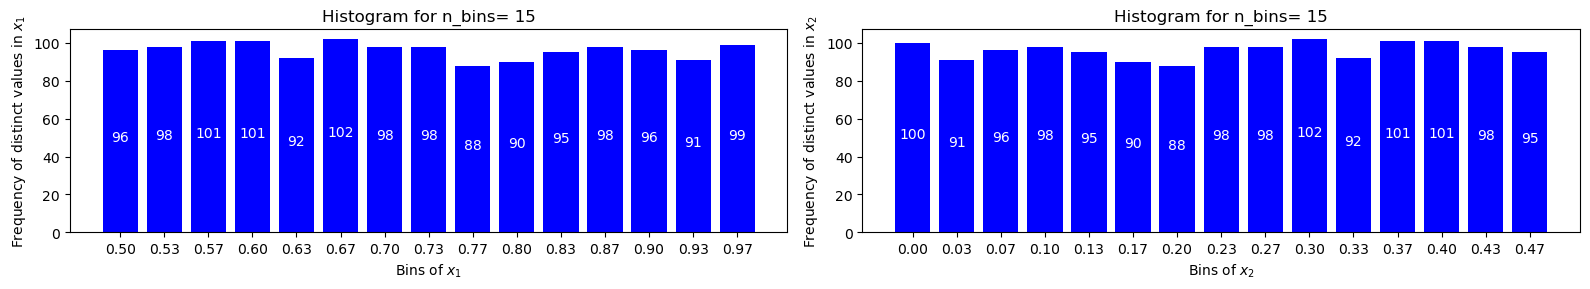

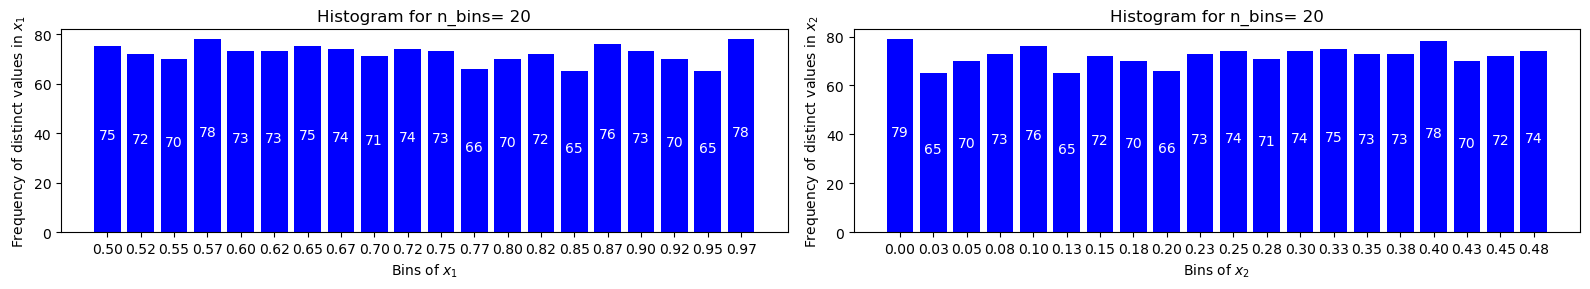

In [86]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex1/'+'ex1_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

In [87]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats
# from matplotlib import pyplot
# from numpy.random import normal
# from numpy import hstack
# from statsmodels.distributions.empirical_distribution import ECDF
# # fit a cdf
# ecdf = ECDF(xgsm)
# plt.plot(ecdf.x, ecdf.y)
# plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [88]:
# import numpy as np
# from scipy import stats

# # Example data (replace with your actual data)
# np.random.seed(0)
# data = np.random.uniform(0,1, size=100)

# # Perform KS test against a normal distribution (null hypothesis)
# ks_statistic, p_value = stats.kstest(data, 'norm')

# # Print the results
# print(f"KS Statistic: {ks_statistic}")
# print(f"P-value: {p_value}")

# # Interpret the results
# alpha = 0.05
# if p_value < alpha:
#     print("Reject the null hypothesis that the data is normally distributed.")
# else:
#     print("Cannot reject the null hypothesis that the data is normally distributed.")


In [89]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats

# # Example data (replace with your actual data)
# np.random.seed(0)
# # data = np.random.normal(loc=0, scale=1, size=100)

# # Sort the data
# sorted_data = np.sort(data)

# # Calculate the empirical CDF
# n = sorted_data.size
# y_empirical = np.arange(1, n+1) / n

# # Calculate the theoretical CDF (normal distribution)
# mean, std = np.mean(data), np.std(data)
# y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# # Plotting the empirical and theoretical CDFs
# plt.figure(figsize=(8, 4))
# plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
# plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
# plt.xlabel('Values')
# plt.ylabel('Cumulative Probability')
# plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
# plt.legend()
# plt.grid(True)
# plt.show()


In [90]:
# # KS Test on x: 
# a,b= 0.5,1
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(x)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(xgsm)
# ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# # plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples vs. Empiric')
# plt.xlabel('$x_1$ values')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../GSM/solns_runs/Ex1/ks_ex1_x1.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

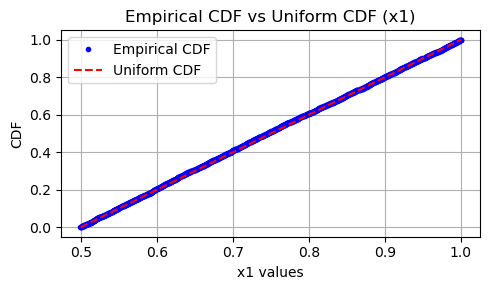

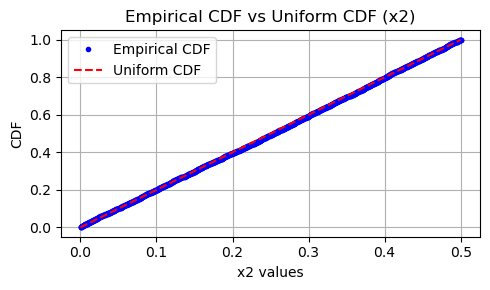

--- x1 ---
K-S Statistic: 0.0130
P-Value: 0.9652
Result: Fail to reject H0 → Sample follows Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.0123
P-Value: 0.9792
Result: Fail to reject H0 → Sample follows Uniform(0,0.5)



In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_gsm_x = ECDF(xgsm)
x1 = ecdf_gsm_x.x       # First coordinate
ecdf_gsm_y = ECDF(ygsm)
x2 = ecdf_gsm_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(x1, a1, b1, 'x1')
plot_ecdf_vs_uniform(x2, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

In [92]:
ecdf_gsm_x.y

array([0.00000000e+00, 6.92520776e-04, 1.38504155e-03, ...,
       9.98614958e-01, 9.99307479e-01, 1.00000000e+00])

In [93]:
ecdf_gsm_x.x

array([      -inf, 0.49965519, 0.50000001, ..., 0.99955808, 0.99972365,
       0.99986948])

In [94]:
# # KS Test on y: 
# # Number of samples
# a,b= 0.0, 0.5
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# n_samples = len(x)
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(ygsm)
# ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# # plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples')
# plt.xlabel('$x_2$ values')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../GSM/solns_runs/Ex1/ks_ex1_x2.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [95]:
# 

In [96]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
        distinct_points= np.array(distinct_points)
            
        all_solns.append(distinct_points)
    return all_solns

data_gsm= plot_solns(folders)

# PVI

In [97]:
## New
## Load data

import json
number_points_list=  [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
nubmer_points_list= number_points_list

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex1PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict


for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                # if constraint_function(dataT[str(T)][i][t])<= 1e-8:
                if dataT[str(T)][i][t] != [0,0]:
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all

res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

data_all= res_all
data= data_all

In [98]:
data[6]

[[0.7979956047600165, 0.20200439523998345],
 [0.8015693986556791, 0.19843060134423526],
 [0.7967838109657827, 0.2032161890342173],
 [0.7617870262889544, 0.23821297371104566],
 [0.8031099773628254, 0.1968900226371976],
 [0.8017498617223116, 0.19825013827762614],
 [0.7914568761302749, 0.20854312386972515],
 [0.7893700148397281, 0.2106299851602719],
 [0.7861094433605963, 0.21389055663940365],
 [0.7872752317170628, 0.2127247682829372],
 [0.8019723782471494, 0.19802762175289235],
 [0.8021563441331637, 0.19784365586683617],
 [0.8004134091432163, 0.19958659085681085],
 [0.7962080818595153, 0.2037919181404848],
 [0.7708958377473986, 0.22910416225260133],
 [0.6802482653846883, 0.3197517346153118],
 [0.7766922456875255, 0.22330775431247446],
 [0.7792117640812762, 0.2207882359187238],
 [0.7817411752162939, 0.21825882478370612],
 [0.7978744516695696, 0.2021255483304304],
 [0.732091455466642, 0.2679085445333581],
 [0.7932071436236716, 0.20679285637632833],
 [0.7983398090921522, 0.2016601909078478],

0 176 1151
1 346 2299
2 506 3438
3 658 4582
4 855 5733
5 1024 6865
6 1197 8022
7 1405 9164
8 1520 10302
9 1707 11450
10 1851 12613
11 2007 13737
12 2195 14882
13 2355 16038
14 2580 17170


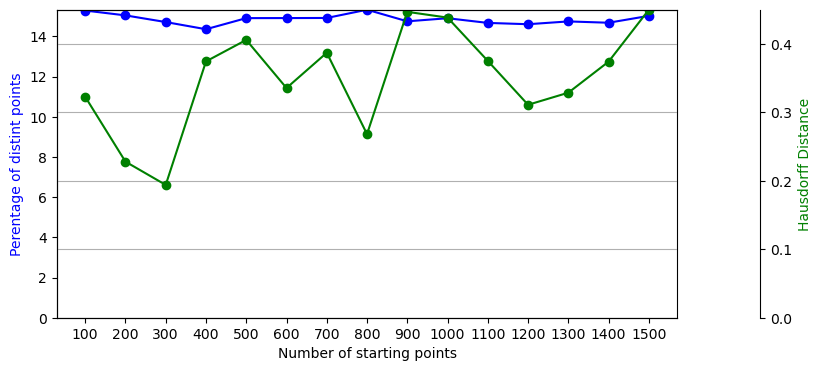

In [99]:
dist_= []
avg_hd= []
tolerancespvi= []
accuracypvi= []


for i in range(len(data)):


    num, distinct_points= count_repeated_points(np.array(data[i]))
    distinct_points= np.array(distinct_points)
    
    print(i, num, len(np.array(data[i])))
            
    dist_.append((len(distinct_points)/(len(data[i])))*100)
    
    t_values = np.random.uniform(0.5, 1, len(np.array(distinct_points)))

    points = np.column_stack((t_values, 1 - t_values))
            
    hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
#     hd.append(hausdorff_distance)
            

    avg_hd.append(hausdorff_distance)
#     tolerancespvi.append(tol)
    
    accuracypvi.append(get_accuracy(distinct_points))
    
    
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex1/plot_ex1.png')
plt.grid(True)
plt.show()

In [115]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [116]:
# for i in range(len(data)):
#     print(len(data[i]), nubmer_points_list[i]*50)

In [117]:
pdppvi

[15.291051259774111,
 15.050021748586342,
 14.717859220477022,
 14.360541248363159,
 14.91365777080063,
 14.916241806263656,
 14.921465968586386,
 15.331732867743344,
 14.754416618132401,
 14.908296943231441,
 14.675334971854436,
 14.610176894518453,
 14.749361644940196,
 14.683875794986905,
 15.02620850320326]

In [118]:
hdgpvi

[0.3229380991990047,
 0.22811378260434198,
 0.19412658809229522,
 0.3746579605376466,
 0.40607960834965795,
 0.3357596162436257,
 0.3873063713907967,
 0.2683680087010921,
 0.4471095968704274,
 0.43868518386083794,
 0.375390231658858,
 0.31125684426327327,
 0.32892227255792106,
 0.37427785477393133,
 0.45020562751189697]

## Metrics using all points: START

In [119]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [120]:
##  Ratio
len(data), len(data_all)

(15, 15)

In [121]:
# for num in nubmer_points_list:
#     print(len(data_all)/(num*10))

In [122]:
pdppvi_all

[15.291051259774111,
 15.050021748586342,
 14.717859220477022,
 14.360541248363159,
 14.91365777080063,
 14.916241806263656,
 14.921465968586386,
 15.331732867743344,
 14.754416618132401,
 14.908296943231441,
 14.675334971854436,
 14.610176894518453,
 14.749361644940196,
 14.683875794986905,
 15.02620850320326]

In [123]:
hdgpvi_all

[0.3229380991990047,
 0.22811378260434198,
 0.19412658809229522,
 0.3746579605376466,
 0.40607960834965795,
 0.3357596162436257,
 0.3873063713907967,
 0.2683680087010921,
 0.4471095968704274,
 0.43868518386083794,
 0.375390231658858,
 0.31125684426327327,
 0.32892227255792106,
 0.37427785477393133,
 0.45020562751189697]

In [124]:
# total= 0
# r= []
# for i in range(len(data_all)):
#     #total= ()/(50)
#     print(len(data_all[i]), len(data[i]), "Ratio: ", len(data[i])/len(data_all[i]))
#     r.append(len(data[i])/len(data_all[i]))

## END

In [125]:
# plt.plot(nubmer_points_list,tolerancespvi,c='b')
# plt.xticks(nubmer_points_list)
# plt.grid(True)
# plt.show()

In [126]:
# accuracypvi

In [127]:
max(dist_), min(avg_hd), max(accuracypvi)

(15.331732867743344, 0.19412658809229522, 98.84393063583815)

In [134]:
sol= np.array(data[np.argmax(pdppvi)])  #np.array(data[14]) #
num, distinct_points= count_repeated_points(sol)
sol= np.array(distinct_points)
print(len(sol))

1405


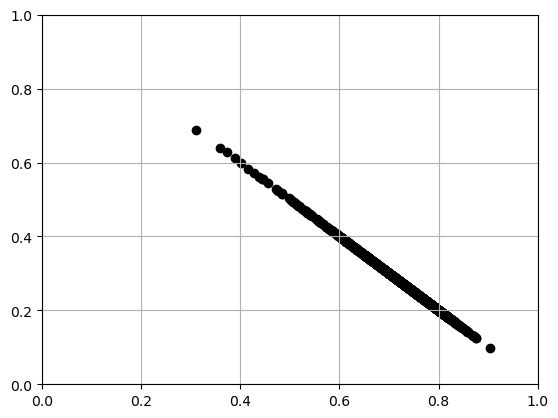

In [135]:
plt.scatter(sol[:,0], sol[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.show()

In [136]:
# for i in range(len(data)):
#     print("Plot for {} points".format(nubmer_points_list[i]))
#     plt.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], c= 'black')
#     plt.xlim([0,1])
#     plt.ylim([0,1])
#     plt.grid(True)
#     plt.show()

In [137]:
hdgpvi

[0.3229380991990047,
 0.22811378260434198,
 0.19412658809229522,
 0.3746579605376466,
 0.40607960834965795,
 0.3357596162436257,
 0.3873063713907967,
 0.2683680087010921,
 0.4471095968704274,
 0.43868518386083794,
 0.375390231658858,
 0.31125684426327327,
 0.32892227255792106,
 0.37427785477393133,
 0.45020562751189697]

## Histogram

In [138]:
## x:
bins_list= [5, 10, 15, 20]
solns= sol.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

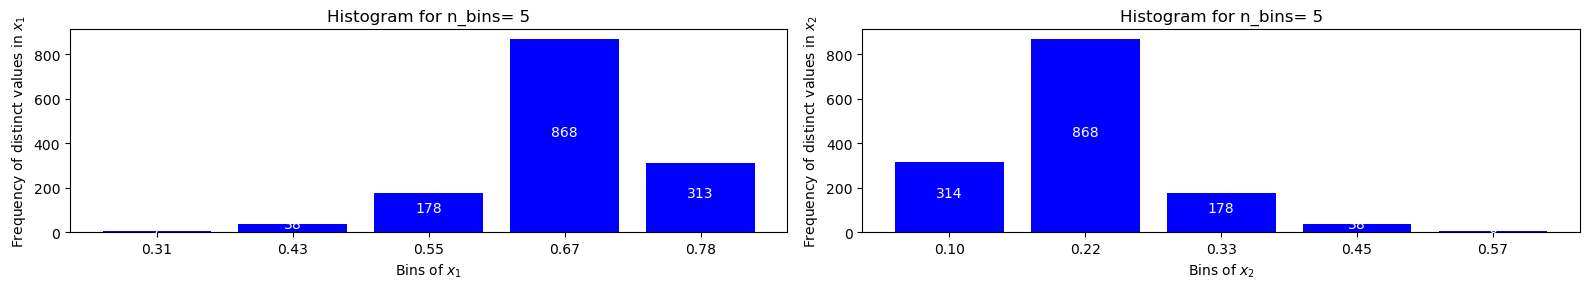

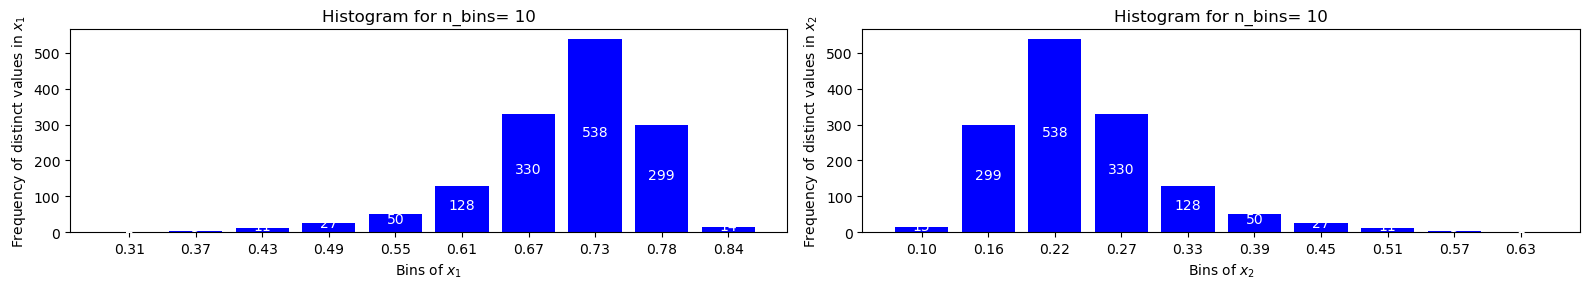

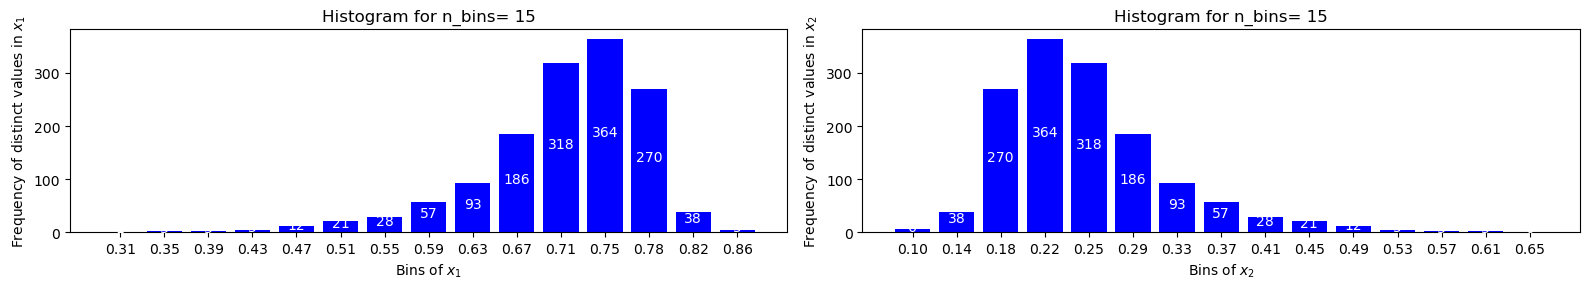

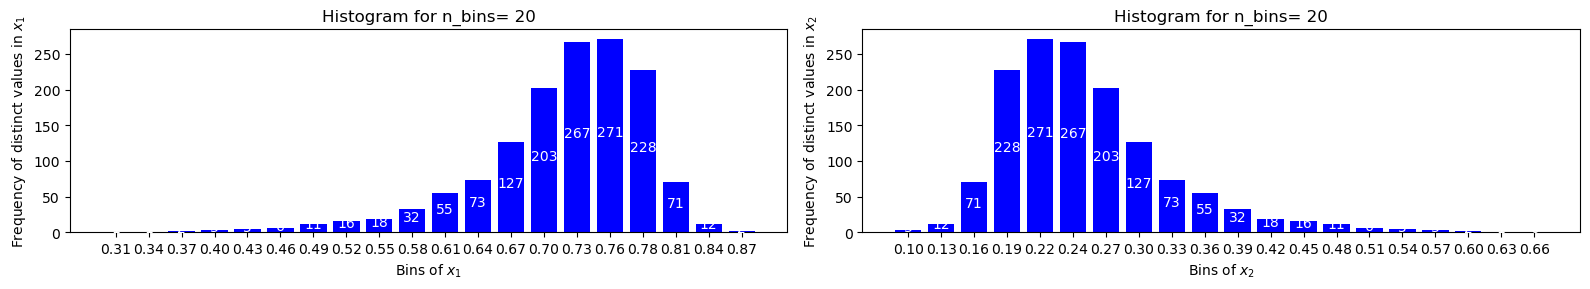

In [139]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../PVI/solns_runs/Ex1/'+'ex1_pvi_hist'+str(n_bins)+'.png')
    plt.show()

In [140]:
for (p,h) in zip(dist_,avg_hd):
    print(p, " * ", h)

15.291051259774111  *  0.3229380991990047
15.050021748586342  *  0.22811378260434198
14.717859220477022  *  0.19412658809229522
14.360541248363159  *  0.3746579605376466
14.91365777080063  *  0.40607960834965795
14.916241806263656  *  0.3357596162436257
14.921465968586386  *  0.3873063713907967
15.331732867743344  *  0.2683680087010921
14.754416618132401  *  0.4471095968704274
14.908296943231441  *  0.43868518386083794
14.675334971854436  *  0.375390231658858
14.610176894518453  *  0.31125684426327327
14.749361644940196  *  0.32892227255792106
14.683875794986905  *  0.37427785477393133
15.02620850320326  *  0.45020562751189697


## Uniform CDF vs. empirical CDF and KS-Test

In [141]:
# # KS Test on x: 
# a,b= 0.5,1
# uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(xpvi)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(xpvi)
# ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# # plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples vs. Empiric')
# plt.xlabel('Value of $x_1$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex1/ks_ex1_x1.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [142]:
# T= 50

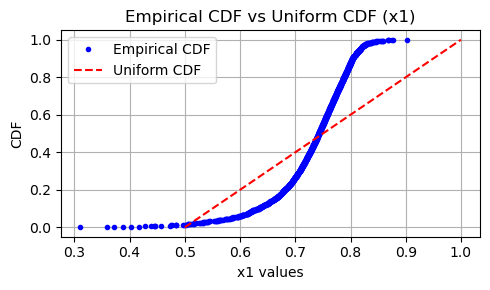

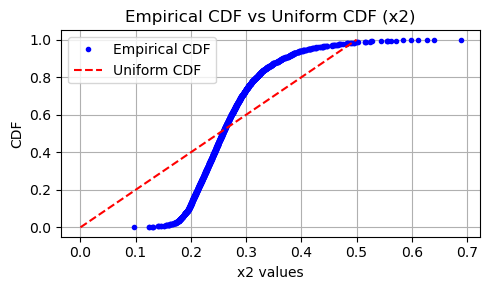

--- x1 ---
K-S Statistic: 0.3221
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.3214
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0,0.5)



In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_pvi_x = ECDF(xpvi)
x1 = ecdf_pvi_x.x       # First coordinate
ecdf_pvi_y = ECDF(ypvi)
x2 = ecdf_pvi_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(xpvi, a1, b1, 'x1')
plot_ecdf_vs_uniform(ypvi, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

In [144]:
# pdp, hd= get_values(folders)

# BFGS

In [145]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [146]:
main_path = "../Merit/solns_runs/Ex1/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex1/N_100/',
 '../Merit/solns_runs/Ex1/N_200/',
 '../Merit/solns_runs/Ex1/N_300/',
 '../Merit/solns_runs/Ex1/N_400/',
 '../Merit/solns_runs/Ex1/N_500/',
 '../Merit/solns_runs/Ex1/N_600/',
 '../Merit/solns_runs/Ex1/N_700/',
 '../Merit/solns_runs/Ex1/N_800/',
 '../Merit/solns_runs/Ex1/N_900/',
 '../Merit/solns_runs/Ex1/N_1000/',
 '../Merit/solns_runs/Ex1/N_1100/',
 '../Merit/solns_runs/Ex1/N_1200/',
 '../Merit/solns_runs/Ex1/N_1300/',
 '../Merit/solns_runs/Ex1/N_1400/',
 '../Merit/solns_runs/Ex1/N_1500/']

In [147]:
# xgsm
# ygsm
# ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
# ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
# ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
# ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

In [148]:
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(res_solns), len(distinct_points))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

1000 313
2000 629
3000 974
4000 1269
5000 1533
6000 1903
7000 2161
8000 2570
9000 2884
10000 3252
11000 3439
12000 3892
13000 4219
14000 4325
15000 4849


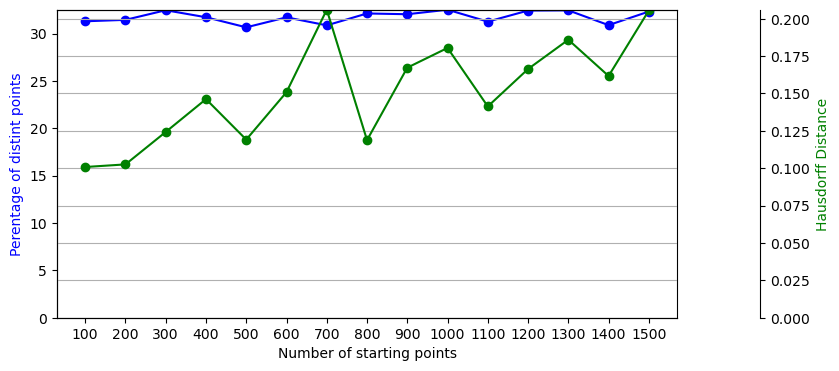

In [149]:
pdpbfgs, hdbfgs,accuracybfgs= get_values(folders)

In [150]:
for (p,h,acc) in zip(pdpbfgs,hdbfgs, accuracybfgs):
    print(p, " * ", h, ' * ', acc)

31.3  *  0.10082327442728327  *  94.24920127795528
31.45  *  0.10256552660811394  *  95.38950715421304
32.46666666666667  *  0.12427085091582309  *  94.35318275154005
31.724999999999998  *  0.14622883506125656  *  95.82348305752562
30.659999999999997  *  0.11914778358966903  *  94.25962165688193
31.716666666666665  *  0.1508976206113889  *  94.27220178665266
30.871428571428574  *  0.20603669530292099  *  95.0948634891254
32.125  *  0.11880490090599759  *  95.01945525291828
32.044444444444444  *  0.1672731976268886  *  94.20943134535368
32.519999999999996  *  0.18045996102708592  *  93.72693726937268
31.263636363636365  *  0.14134322435417818  *  94.47513812154696
32.43333333333333  *  0.16637930161683293  *  94.57862281603289
32.45384615384616  *  0.1859646908325693  *  93.95591372363118
30.892857142857146  *  0.1617110732459694  *  94.9364161849711
32.32666666666667  *  0.20553386700076096  *  94.18436791090946


In [151]:
max(pdpbfgs), min(hdbfgs), max(accuracybfgs)

(32.519999999999996, 0.10082327442728327, 95.82348305752562)

In [152]:
# plot_solns(folders)

### Histograms

In [155]:
n_points= nubmer_points_list[np.argmax(pdpbfgs)] #1500
directory_path = "../Merit/solns_runs/Ex1/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

    # num, distinct_points= count_repeated_points(solns, len(solns))
    # distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns)

all_solnsbfgs= np.array(all_solnsbfgs)
num, all_solnsbfgs= count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [156]:
len(all_solnsbfgs)

3252

In [157]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

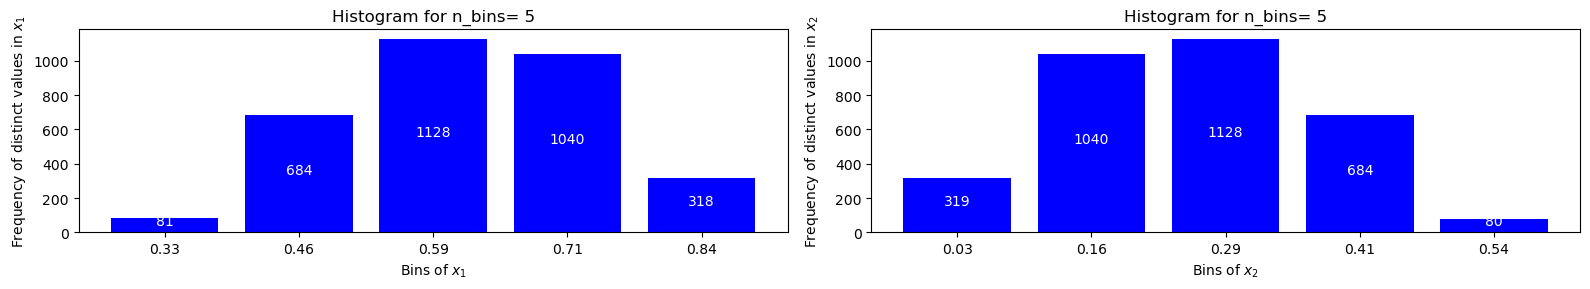

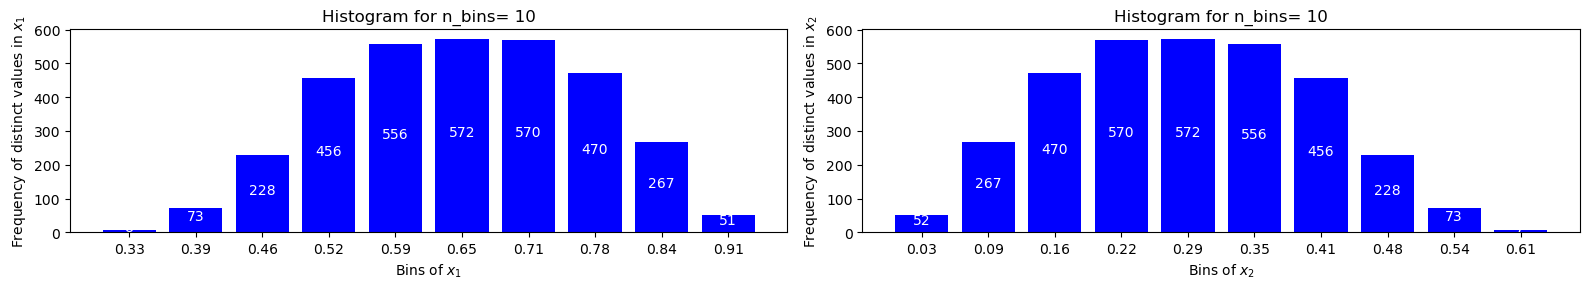

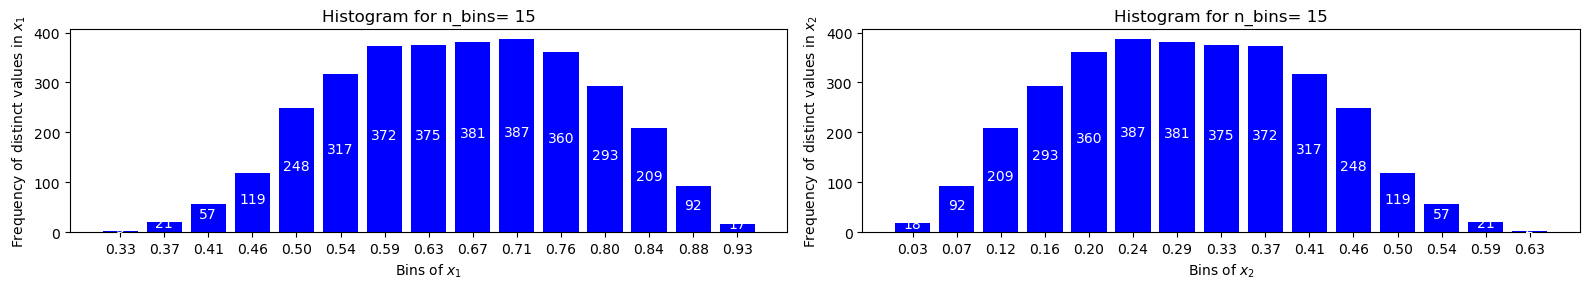

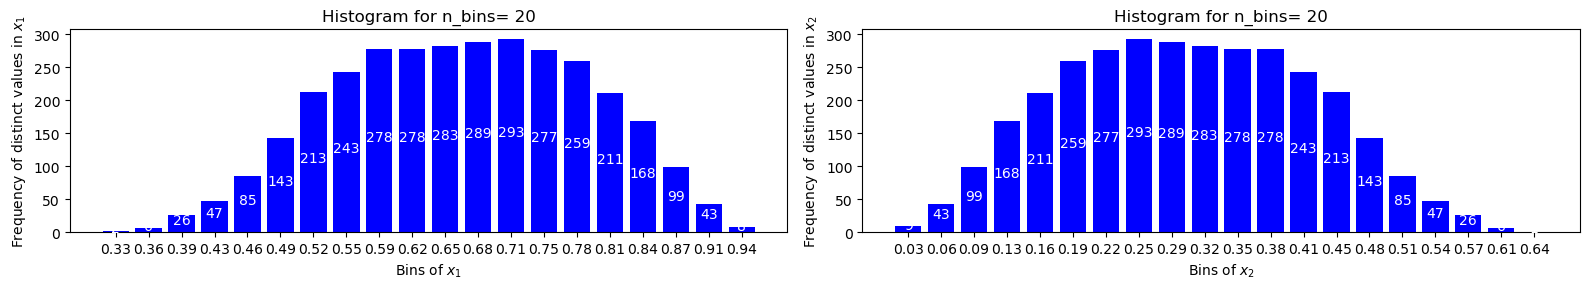

In [158]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex1/'+'ex1_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

In [159]:
#  # KS Test on x: 
# a,b= 0.5,1
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(xbfgs)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(xbfgs)
# ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# # plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples vs. Empiric')
# plt.xlabel('Value of $x_1$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../Merit/solns_runs/Ex1/ks_ex1_x1.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [160]:
# # KS Test on y: 
# # Number of samples
# a,b= 0.0, 0.5
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# n_samples = len(ybfgs)
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(ybfgs)
# ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# # plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples')
# plt.xlabel('Value of $x_2$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../Merit/solns_runs/Ex1/ks_ex1_x2.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

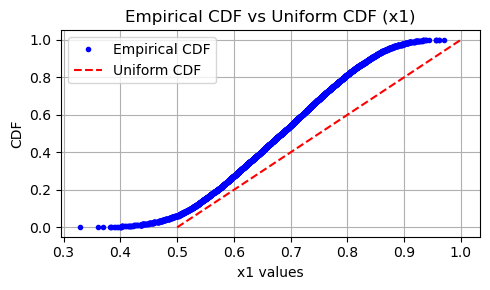

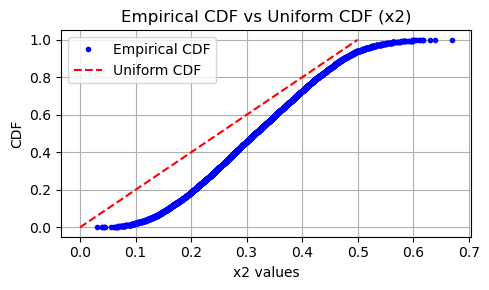

--- x1 ---
K-S Statistic: 0.2202
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.2199
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0,0.5)



In [161]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_bfgs_x = ECDF(xbfgs)
x1 = ecdf_bfgs_x.x       # First coordinate
ecdf_bfgs_y = ECDF(ybfgs)
x2 = ecdf_bfgs_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(xbfgs, a1, b1, 'x1')
plot_ecdf_vs_uniform(ybfgs, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

In [162]:
def get_values(folders):
    res_solns= []
    
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns.append(np.array(res_solns))
    return res_solns

data_bfgs= get_values(folders)

# EIA

## Number of starting points vs. PDP and HD

In [163]:
main_path = "../EIA/solns_runs/Ex1/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

# folders= ["../EIA/solns_runs/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
# folders
folders= ["../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_100/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_200/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_300/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_400/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_500/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_600/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_700/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_800/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_900/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1000/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1100/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1200/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1300/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1400/',
 '../PublicCodes/EIA/Tuning/Ex1/percent/10/Ex1/N_1500/']

In [164]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')[:,:-1]
# #             mask= solns[:,-1]<0.01
# #             solns= solns[:,:-1][mask]
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(len(solns)))*100)
        
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list , avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../EIA/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

In [165]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
            
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
                        
#             res_solns.extend(distinct_points.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        print(len(distinct_points), len(res_solns))
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

#         print(points.shape, distinct_points.shape)
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

182 1000
533 2000
856 3000
1252 4000
1645 5000
2029 6000
2357 7000
2763 8000
3230 9000
3614 10000
3971 11000
4336 12000
4718 13000
5143 14000
5545 15000


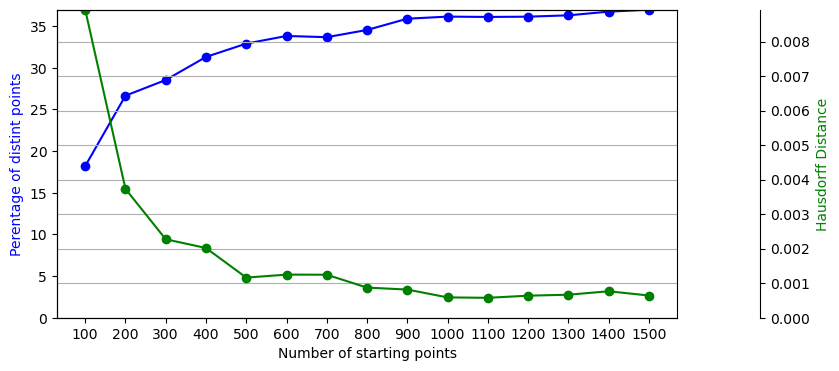

In [166]:
pdpeia, hdeia, accuracyeia= get_values(folders)

In [167]:
for (p,h,acc) in zip(pdpeia,hdeia, accuracyeia):
    print(p, " * ", h, " * ", acc)

18.2  *  0.008922171210151333  *  93.4065934065934
26.650000000000002  *  0.003731506079902877  *  93.43339587242026
28.53333333333333  *  0.002272768732029701  *  94.39252336448598
31.3  *  0.002019533355415225  *  94.40894568690096
32.9  *  0.001162054853675206  *  94.65045592705167
33.81666666666667  *  0.0012488221985090544  *  94.13504189255791
33.67142857142857  *  0.0012456704711521316  *  92.87229529062367
34.5375  *  0.0008729160755665543  *  94.13680781758957
35.888888888888886  *  0.0008159586489048267  *  93.80804953560371
36.14  *  0.0005889532716295485  *  93.96790260099613
36.1  *  0.000576616805798104  *  93.07479224376732
36.13333333333333  *  0.0006387373103263052  *  93.17343173431735
36.29230769230769  *  0.0006661629030002133  *  93.74735057227639
36.73571428571429  *  0.0007663103361196281  *  93.71961889947501
36.96666666666666  *  0.0006434933517465758  *  93.34535617673579


In [172]:
max(pdpeia), min(hdeia), max(accuracyeia)

(36.96666666666666, 0.000576616805798104, 94.65045592705167)

In [173]:
#plot_solns(folders)
np.argmax(pdpeia), np.argmin(hdeia)

(14, 10)

### Histograms

In [174]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)] #1500
# Best
directory_path = "../EIA/solns_runs/Ex1/N_{}".format(n_points)
#directory_path = [-1]#"../EIA/solns_runs/Ex1/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
        files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')
    all_solnseia.extend(solns)
    #all_solnseia.extend(solns.list())

all_solnseia= np.array(all_solnseia)

num, all_solnseia= count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

In [175]:
print(len(all_solnseia))

5664


In [176]:
files

['../EIA/solns_runs/Ex1/N_1500/._10_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._1_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._2_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._3_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._4_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._5_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._6_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._7_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._8_solns_run_10_1500pts.txt',
 '../EIA/solns_runs/Ex1/N_1500/._9_solns_run_10_1500pts.txt']

In [177]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xeia= x.copy()
yeia= y.copy()

In [178]:
len(all_solnseia)

5664

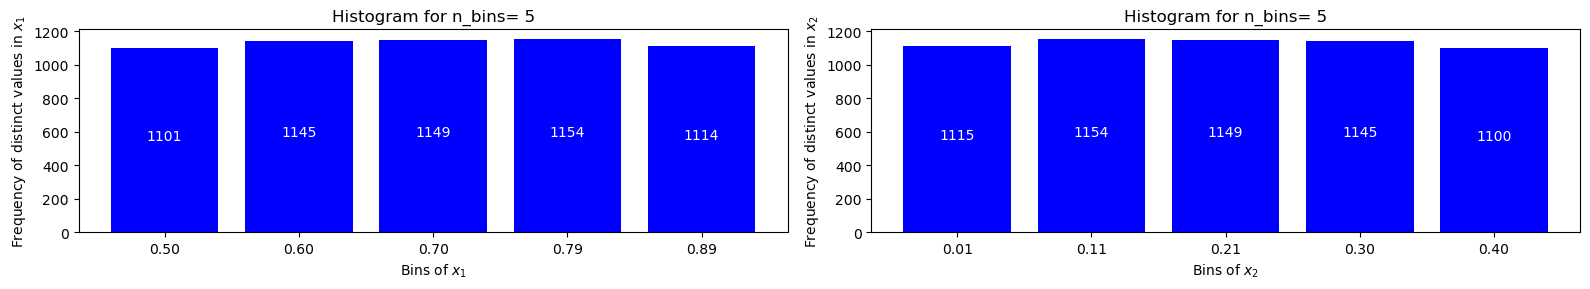

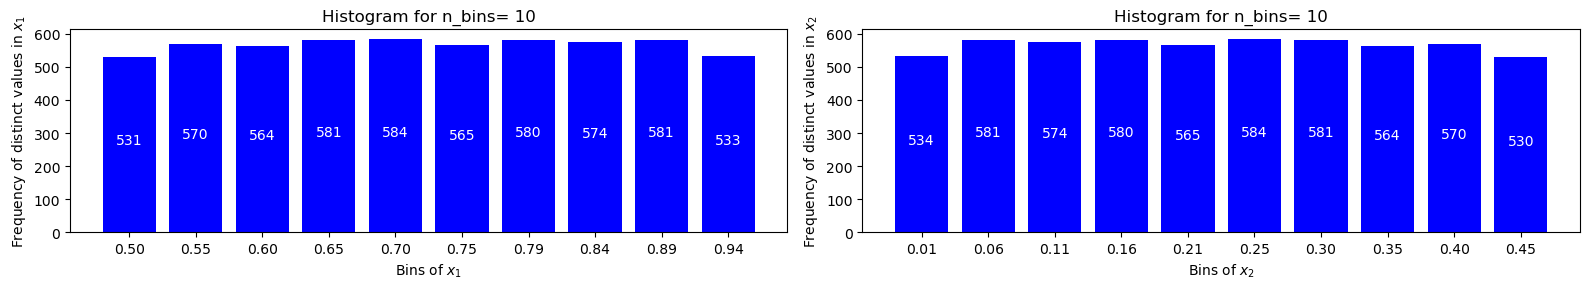

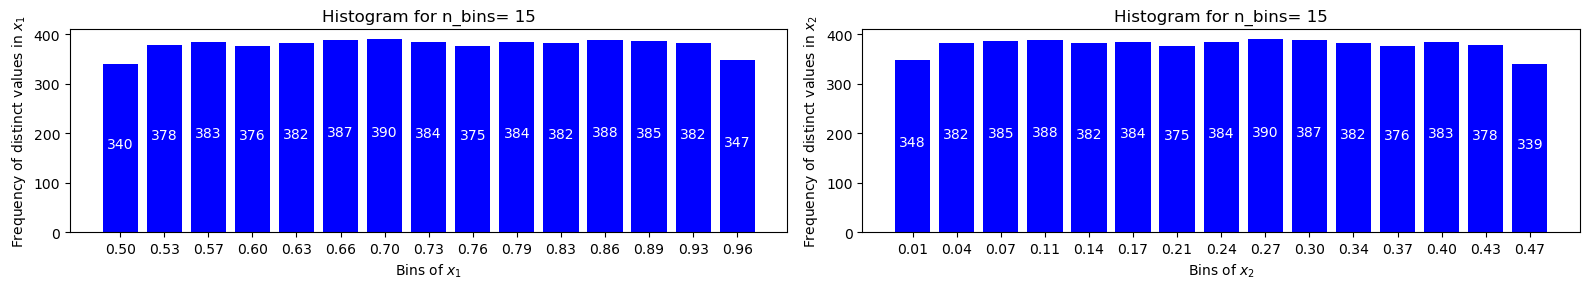

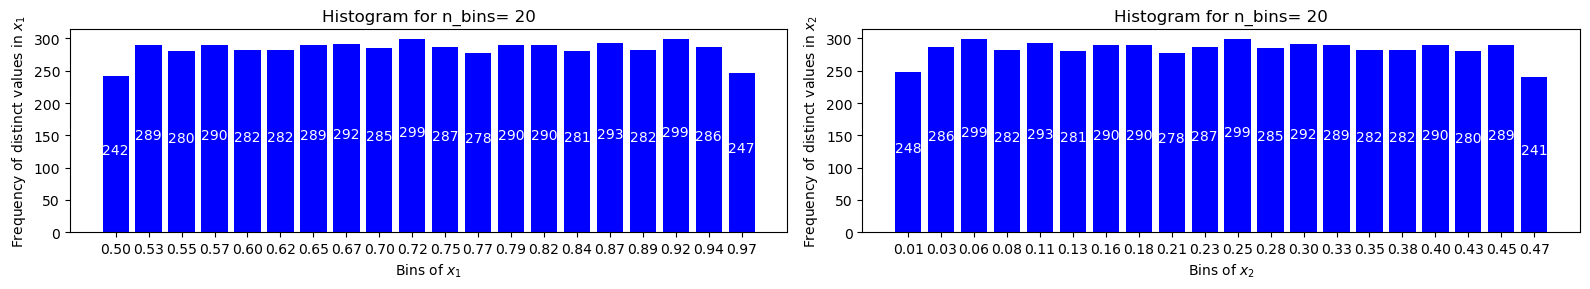

In [179]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex1/'+'ex1_eia_hist'+str(n_bins)+'.png')
    plt.show()

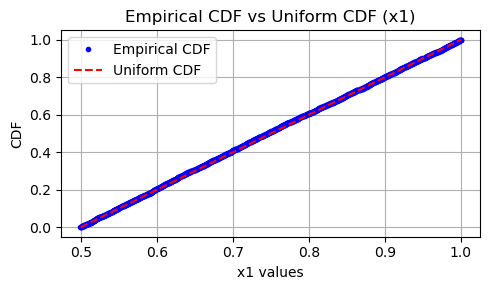

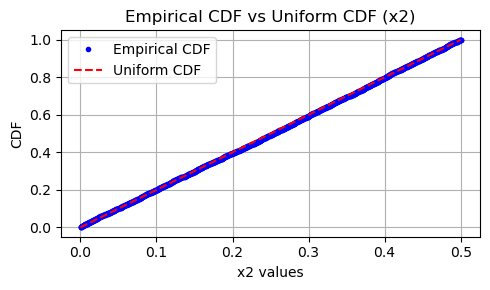

--- x1 ---
K-S Statistic: 0.0130
P-Value: 0.9652
Result: Fail to reject H0 → Sample follows Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.0123
P-Value: 0.9792
Result: Fail to reject H0 → Sample follows Uniform(0,0.5)



In [180]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_gsm_x = ECDF(xgsm)
x1 = ecdf_gsm_x.x       # First coordinate
ecdf_gsm_y = ECDF(ygsm)
x2 = ecdf_gsm_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(x1, a1, b1, 'x1')
plot_ecdf_vs_uniform(x2, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

### Uniform CDF vs. empirical CDF and  KS-Test

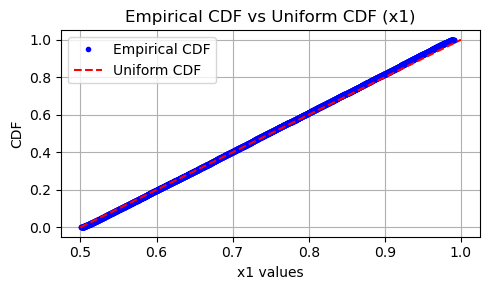

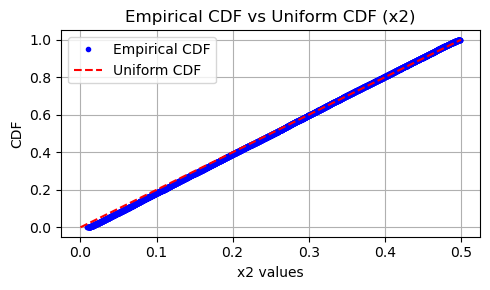

--- x1 ---
K-S Statistic: 0.0245
P-Value: 0.0022
Result: Reject H0 → Sample does NOT follow Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.0243
P-Value: 0.0025
Result: Reject H0 → Sample does NOT follow Uniform(0,0.5)



In [181]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_eia_x = ECDF(xeia)
x1 = ecdf_eia_x.x       # First coordinate
ecdf_eia_y = ECDF(yeia)
x2 = ecdf_eia_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(xeia, a1, b1, 'x1')
plot_ecdf_vs_uniform(yeia, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

In [182]:
# # KS Test on x: 
# a,b= 0.5,1
# uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(xeia)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(xeia)
# ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# # plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples vs. Empiric')
# plt.xlabel('Value of $x_1$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../EIA/solns_runs/Ex1/ks_ex1_x1.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

In [183]:
# # KS Test on y: 
# # Number of samples
# a,b= 0.0, 0.5
# uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# n_samples = len(yeia)
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(yeia)
# ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# # plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples')
# plt.xlabel('Value of $x_2$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../EIA/solns_runs/Ex1/ks_ex1_x2.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(yeia, "uniform")

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [184]:
# ks_statistic,p_value

In [185]:
def get_values(folders):
    res_solns= []
    
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
            
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
                        
#             res_solns.extend(distinct_points.tolist())
        
        
        res_solns.append(np.array(res_solns))
    return res_solns


data_eia= get_values(folders)

# SGD

## Number of starting points vs. PDP and HD

In [186]:
main_path = "../SGD/solns_runs/Ex1/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex1/N_100/',
 '../SGD/solns_runs/Ex1/N_200/',
 '../SGD/solns_runs/Ex1/N_300/',
 '../SGD/solns_runs/Ex1/N_400/',
 '../SGD/solns_runs/Ex1/N_500/',
 '../SGD/solns_runs/Ex1/N_600/',
 '../SGD/solns_runs/Ex1/N_700/',
 '../SGD/solns_runs/Ex1/N_800/',
 '../SGD/solns_runs/Ex1/N_900/',
 '../SGD/solns_runs/Ex1/N_1000/',
 '../SGD/solns_runs/Ex1/N_1100/',
 '../SGD/solns_runs/Ex1/N_1200/',
 '../SGD/solns_runs/Ex1/N_1300/',
 '../SGD/solns_runs/Ex1/N_1400/',
 '../SGD/solns_runs/Ex1/N_1500/']

In [187]:
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        #print(pt)
        #print(files)
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')#[:,:-1]
            #mask= solns[:,-1]<0.01
            #solns= solns[:,:-1][mask]
            solns= solns[:,:-1]
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

582 1000
1336 2000
2178 3000
3055 4000
3955 5000
4951 6000
5881 7000
6804 8000
7779 9000
8722 10000
9680 11000
10760 12000
11786 13000
12726 14000
13641 15000


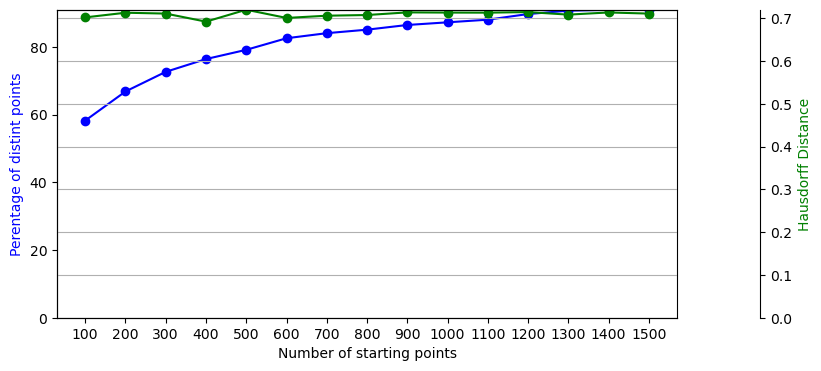

In [188]:
pdpsgd, hdsgd,accuracysgd= get_values(folders)

In [189]:
# list_txt_files_in_directory(folders[10])

In [190]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

58.199999999999996  *  0.7019726857188668
66.8  *  0.7128942447802791
72.6  *  0.7108946902068196
76.375  *  0.6920594331270814
79.10000000000001  *  0.7199101196088435
82.51666666666667  *  0.7006991895722586
84.01428571428572  *  0.7059362280932441
85.05  *  0.7075338618022308
86.43333333333332  *  0.7136902193110386
87.22  *  0.7132397136117595
88.0  *  0.7130504833570541
89.66666666666666  *  0.714429549125074
90.66153846153846  *  0.7084536363134186
90.9  *  0.713520197333057
90.94  *  0.7108866678022419


In [191]:
max(pdpsgd), min(hdsgd)

(90.94, 0.6920594331270814)

In [192]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            mask= solns[:,-1] <0.01
            solns= solns[:,:-1][mask]
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
#         solns= np.genfromtxt(ex1_path+solutions[i], delimiter=',')
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.grid(True)
        plt.show()

In [193]:
# plot_solns(folders)

## Histograms

In [194]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpsgd)] #1500
# Best
directory_path = "../SGD/solns_runs/Ex1/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')
    solns= solns[:,:-1]
    #mask= solns[:,-1]<0.01
    #solns= solns[:,:-1][mask]
#     distinct_points= np.array(distinct_points)
    all_solnssgd.extend(solns.tolist())

all_solnssdg= np.array(all_solnssgd)

num, all_solnssdg= count_repeated_points(all_solnssdg)
all_solnssdg= np.array(all_solnssdg)

In [195]:
len(all_solnssdg)

13641

In [196]:
files

['../SGD/solns_runs/Ex1/N_1500/10_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/1_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/2_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/3_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/4_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/5_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/6_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/7_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/8_solns_run_10_1500pts.txt',
 '../SGD/solns_runs/Ex1/N_1500/9_solns_run_10_1500pts.txt']

(0.0, 1.0)

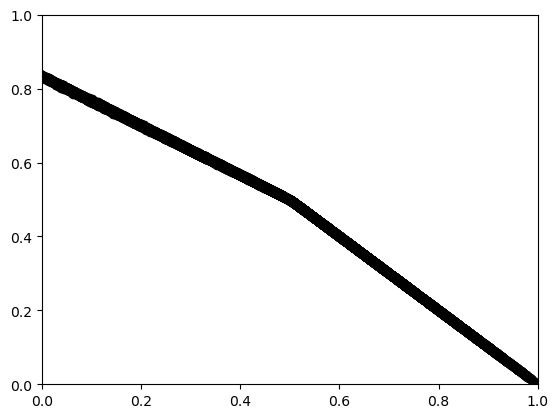

In [197]:
plt.scatter(all_solnssdg[:,0], all_solnssdg[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])

In [198]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssdg.copy()
# mask= solns[:,-1]<0.1
# solns= solns[:,:-1][mask]
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

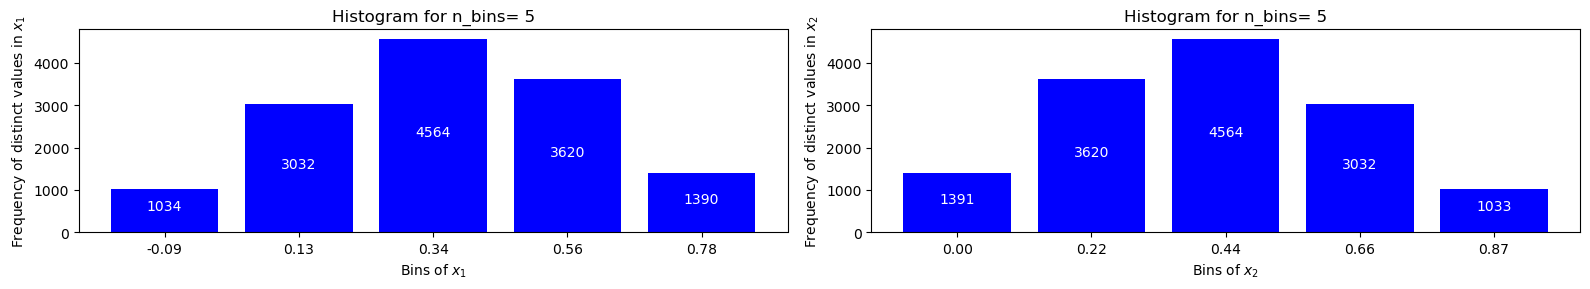

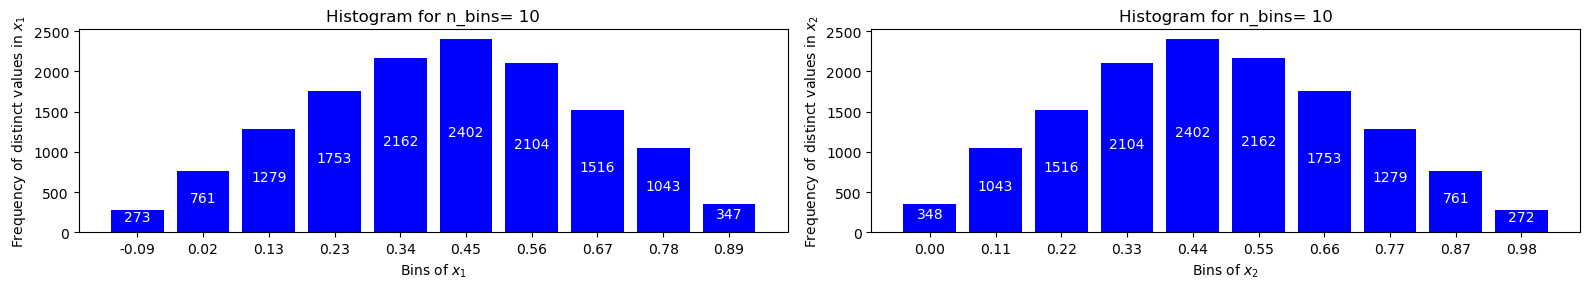

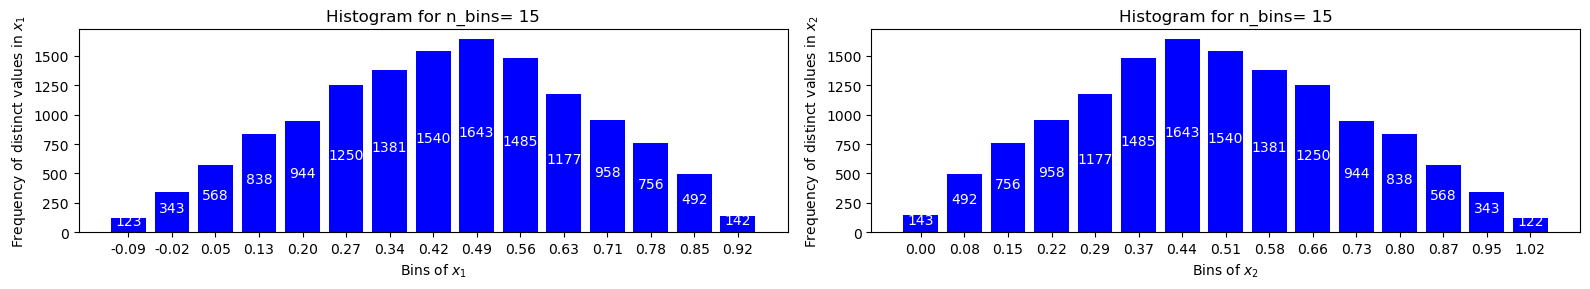

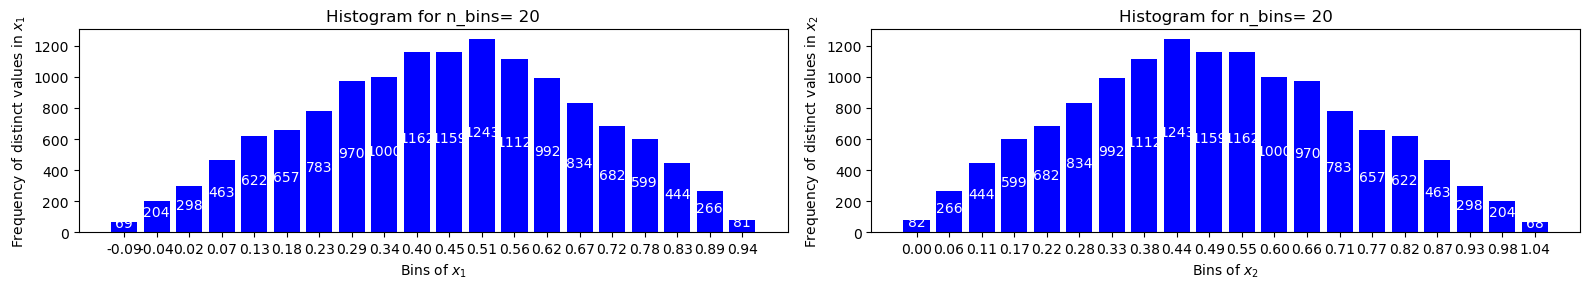

In [199]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex1/'+'ex1_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

In [200]:
# # KS Test on x: 
# a,b= 0.5,1
# uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# # Number of samples
# n_samples = len(xsgd)

# # Generate uniform values in [0,1]
# #uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# # Plotting the histogram of uniform samples
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(xsgd)
# ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# # plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples vs. Empiric')
# plt.xlabel('Value of $x_1$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../SGD/solns_runs/Ex1/ks_ex1_x1.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

In [201]:
# # KS Test on y: 
# # Number of samples
# a,b= 0.0, 0.5
# uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# n_samples = len(ysgd)
# plt.figure(figsize=(5, 3))

# # CDF Plot
# sorted_samples = np.sort(ysgd)
# ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
# plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# # plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# # plt.title('CDF of Uniform Samples')
# plt.xlabel('Value of $x_2$')
# plt.ylabel('CDF')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('../SGD/solns_runs/Ex1/ks_ex1_x2.png')
# plt.show()

# # Perform K-S test
# ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# # Display the results
# print(f"K-S Statistic: {ks_statistic}")
# print(f"P-Value: {p_value}")

# # Decision based on the p-value
# alpha = 0.05
# if p_value > alpha:
#     print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
# else:
#     print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

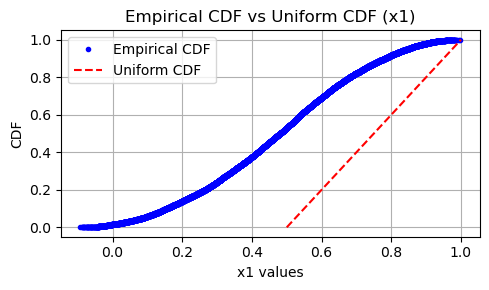

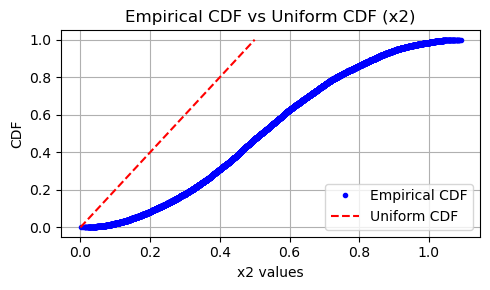

--- x1 ---
K-S Statistic: 0.5299
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.5,1)

--- x2 ---
K-S Statistic: 0.5298
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0,0.5)



In [202]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF

# -------------------------
# 1. Generate data
# -------------------------
n_samples = 200
ecdf_sgd_x = ECDF(xsgd)
x1 = ecdf_sgd_x.x       # First coordinate
ecdf_sgd_y = ECDF(ysgd)
x2 = ecdf_sgd_y.x   # Second coordinate

# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

# -------------------------
# 3. Function to plot ECDF vs Uniform CDF
# -------------------------
def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------
# 4. Plot ECDF vs Uniform CDF
# -------------------------
plot_ecdf_vs_uniform(xsgd, a1, b1, 'x1')
plot_ecdf_vs_uniform(ysgd, a2, b2, 'x2')

# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

ks_test(x1, a1, b1, 'x1')
ks_test(x2, a2, b2, 'x2')

In [203]:
def get_values(folders):
    res_solns= []
   
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        #print(pt)
        #print(files)
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')#[:,:-1]
            #mask= solns[:,-1]<0.01
            #solns= solns[:,:-1][mask]
            solns= solns[:,:-1]
            res_solns.extend(solns.tolist())

        res_solns.append(np.array(res_solns))
    return res_solns

data_sgd= get_values(folders)

# KS-Overall

In [204]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

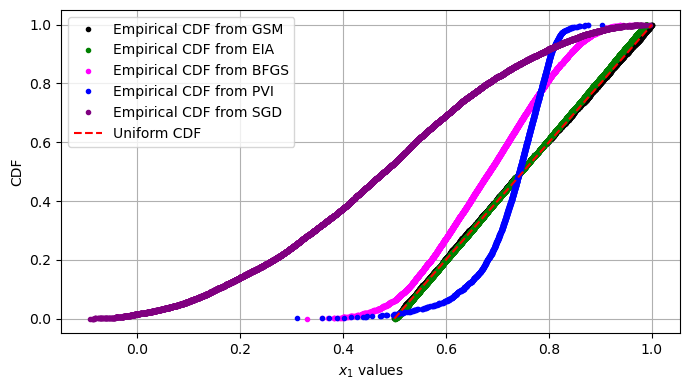

GSM
K-S Statistic: 0.0122
P-Value: 0.9805
Result: Fail to reject H0 → Sample follows Uniform(0.49965518751624316,0.9998694793087488)

*********
EIA
K-S Statistic: 0.0074
P-Value: 0.9093
Result: Fail to reject H0 → Sample follows Uniform(0.5007219266517048,0.9909160767371108)

*********
BFGS
K-S Statistic: 0.2074
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.3295439852541475,0.9699411027418936)

*********
PVI
K-S Statistic: 0.4477
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.31104611114716413,0.9030562388165521)

*********
SGD
K-S Statistic: 0.1306
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(-0.09204842376713483,0.9971824879842194)

*********


In [205]:
# KS Test on x: 
a,b= 0.5,1.0
# uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/all_ks_ex1_x1.png')
plt.show()

# KS_Test(xgsm, algo= "GSM")
# KS_Test(xeia, algo= "EIA")
# KS_Test(xbfgs, algo= "BFGS")
# KS_Test(xpvi, algo= "PVI")
# KS_Test(xsgd, algo= "SGD")

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

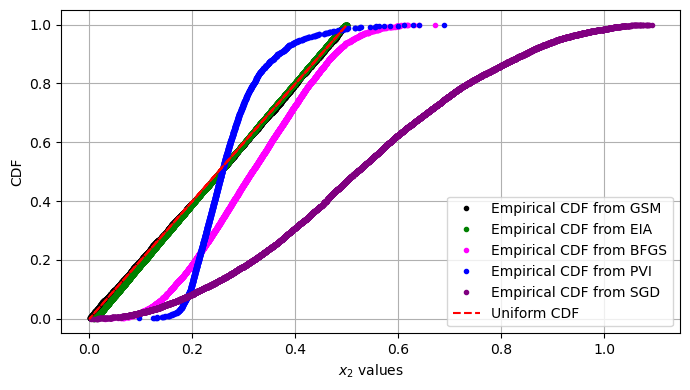

GSM
K-S Statistic: 0.0122
P-Value: 0.9805
Result: Fail to reject H0 → Sample follows Uniform(0.00013052069125119026,0.5003448124837568)

*********
EIA
K-S Statistic: 0.0074
P-Value: 0.9093
Result: Fail to reject H0 → Sample follows Uniform(0.009083923262889204,0.4992780733482952)

*********
BFGS
K-S Statistic: 0.2074
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0300588972581064,0.6704560147458525)

*********
PVI
K-S Statistic: 0.4477
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.09694376118344794,0.6889538888528359)

*********
SGD
K-S Statistic: 0.1306
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.002817512015780621,1.0920484237671348)

*********


In [206]:
# KS Test on y: 
# Number of samples
a,b= 0.0,0.5
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/all_ks_ex1_x2.png')
plt.show()

print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")
    
# KS_Test(ygsm, algo= "GSM")
# KS_Test(yeia, algo= "EIA")
# KS_Test(ybfgs, algo= "BFGS")
# KS_Test(ypvi, algo= "PVI")
# KS_Test(ysgd, algo= "SGD")

In [207]:
ecdfsgd.x, ecdfsgd.y

(array([      -inf, 0.00281751, 0.00608139, ..., 1.08615852, 1.08741312,
        1.09204842]),
 array([0.00000000e+00, 7.33084085e-05, 1.46616817e-04, ...,
        9.99853383e-01, 9.99926692e-01, 1.00000000e+00]))

In [208]:
# pdppvi, hdgpvi
pdpeia

[18.2,
 26.650000000000002,
 28.53333333333333,
 31.3,
 32.9,
 33.81666666666667,
 33.67142857142857,
 34.5375,
 35.888888888888886,
 36.14,
 36.1,
 36.13333333333333,
 36.29230769230769,
 36.73571428571429,
 36.96666666666666]

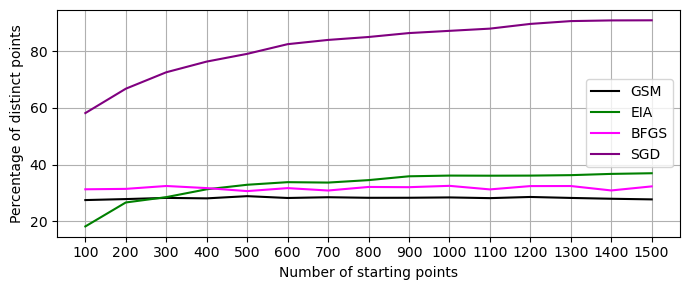

In [209]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/npoints_pdp.png')
plt.show()

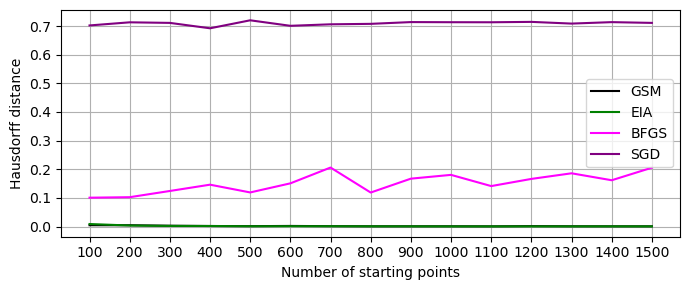

In [210]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/npoints_hd.png')
plt.show()

### Hists

In [211]:
# x_hist_sgd= []
# y_hist_sgd= []
# y_part_sgd= []
# x_part_sgd= []
# hdgpvi

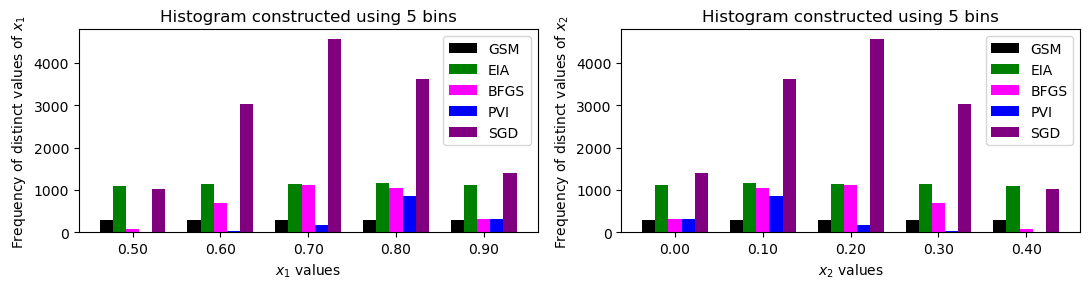

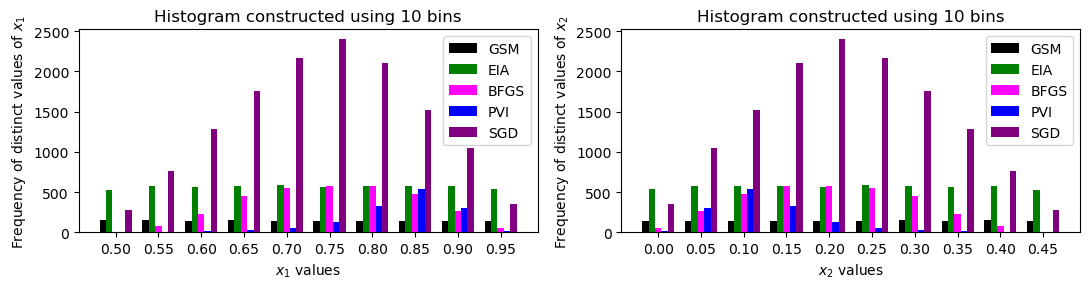

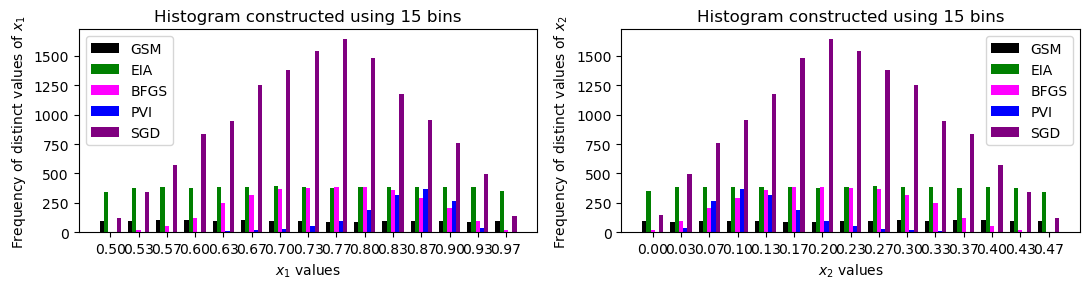

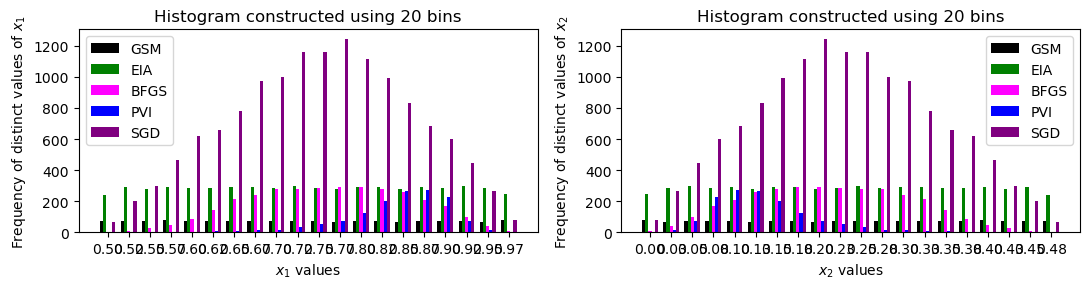

In [212]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values of $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_2$ values')
    plt.ylabel('Frequency of distinct values of $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex1/'+'ex1_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


# END

In [213]:
len(xeia),len(xsgd),len(xgsm),len(xbfgs),len(xpvi)

(5664, 13641, 1444, 3252, 1405)

In [214]:
Ex1Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

In [215]:
Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

In [216]:
for (idx, algo) in enumerate(Algorithms):

    Ex1Sols[algo]["hd"]= HDResults[idx]
    Ex1Sols[algo]["pdp"]= PDPResults[idx]
    # Ex1Sols[algo]["solutions"]= dataSol[idx]

In [217]:
import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex1Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex1Sols, f, indent=4, default=convert_ndarray)

In [218]:
import json

with open("Ex1Sols.json", "r", encoding="utf-8") as f:
    Ex1Sols_loaded = json.load(f)

print(Ex1Sols_loaded)

{'EIA': {'hd': [0.008922171210151333, 0.003731506079902877, 0.002272768732029701, 0.002019533355415225, 0.001162054853675206, 0.0012488221985090544, 0.0012456704711521316, 0.0008729160755665543, 0.0008159586489048267, 0.0005889532716295485, 0.000576616805798104, 0.0006387373103263052, 0.0006661629030002133, 0.0007663103361196281, 0.0006434933517465758], 'pdp': [18.2, 26.650000000000002, 28.53333333333333, 31.3, 32.9, 33.81666666666667, 33.67142857142857, 34.5375, 35.888888888888886, 36.14, 36.1, 36.13333333333333, 36.29230769230769, 36.73571428571429, 36.96666666666666], 'solutions': None}, 'SGD': {'hd': [0.7019726857188668, 0.7128942447802791, 0.7108946902068196, 0.6920594331270814, 0.7199101196088435, 0.7006991895722586, 0.7059362280932441, 0.7075338618022308, 0.7136902193110386, 0.7132397136117595, 0.7130504833570541, 0.714429549125074, 0.7084536363134186, 0.713520197333057, 0.7108866678022419], 'pdp': [58.199999999999996, 66.8, 72.6, 76.375, 79.10000000000001, 82.51666666666667, 84